In [2]:
import numpy as np
import pandas as pd

In [4]:
l01_fold0 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_fountain/lambda/lambda_0.1/fold0_0.5_genomic_windows_table_results.tsv", sep="\t")
l01_fold0["fold"] = [0 for i in range(len(l01_fold0))]
l01_fold0["lambda"] = [0.1 for i in range(len(l01_fold0))]

In [5]:
l01_fold1 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_fountain/lambda/lambda_0.1/fold1_0.5_genomic_windows_table_results.tsv", sep="\t")
l01_fold1["fold"] = [1 for i in range(len(l01_fold1))]
l01_fold1["lambda"] = [0.1 for i in range(len(l01_fold1))]

In [6]:
l01_fold2 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_fountain/lambda/lambda_0.1/fold2_0.5_genomic_windows_table_results.tsv", sep="\t")
l01_fold2["fold"] = [2 for i in range(len(l01_fold2))]
l01_fold2["lambda"] = [0.1 for i in range(len(l01_fold2))]

In [7]:
l1_fold0 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_fountain/lambda/lambda_1.0/fold0_0.5_genomic_windows_table_results.tsv", sep="\t")
l1_fold0["fold"] = [0 for i in range(len(l1_fold0))]
l1_fold0["lambda"] = [1.0 for i in range(len(l1_fold0))]

In [8]:
l1_fold1 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_fountain/lambda/lambda_1.0/fold1_0.5_genomic_windows_table_results.tsv", sep="\t")
l1_fold1["fold"] = [1 for i in range(len(l1_fold1))]
l1_fold1["lambda"] = [1.0 for i in range(len(l1_fold1))]

In [9]:
l1_fold2 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_fountain/lambda/lambda_1.0/fold2_0.5_genomic_windows_table_results.tsv", sep="\t")
l1_fold2["fold"] = [2 for i in range(len(l1_fold2))]
l1_fold2["lambda"] = [1.0 for i in range(len(l1_fold2))]

In [10]:
l10_fold0 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_fountain/lambda/lambda_10.0/fold0_0.5_genomic_windows_table_results.tsv", sep="\t")
l10_fold0["fold"] = [0 for i in range(len(l10_fold0))]
l10_fold0["lambda"] = [10.0 for i in range(len(l10_fold0))]

In [11]:
l10_fold1 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_fountain/lambda/lambda_10.0/fold1_0.5_genomic_windows_table_results.tsv", sep="\t")
l10_fold1["fold"] = [1 for i in range(len(l10_fold1))]
l10_fold1["lambda"] = [10.0 for i in range(len(l10_fold1))]

In [12]:
l10_fold2 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_fountain/lambda/lambda_10.0/fold2_0.5_genomic_windows_table_results.tsv", sep="\t")
l10_fold2["fold"] = [2 for i in range(len(l10_fold2))]
l10_fold2["lambda"] = [10.0 for i in range(len(l10_fold2))]

In [13]:
l100_fold0 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_fountain/lambda/lambda_100.0/fold0_0.5_genomic_windows_table_results.tsv", sep="\t")
l100_fold0["fold"] = [0 for i in range(len(l100_fold0))]
l100_fold0["lambda"] = [100.0 for i in range(len(l100_fold0))]

In [14]:
l100_fold1 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_fountain/lambda/lambda_100.0/fold1_0.5_genomic_windows_table_results.tsv", sep="\t")
l100_fold1["fold"] = [1 for i in range(len(l100_fold1))]
l100_fold1["lambda"] = [100.0 for i in range(len(l100_fold1))]

In [15]:
l100_fold2 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_fountain/lambda/lambda_100.0/fold2_0.5_genomic_windows_table_results.tsv", sep="\t")
l100_fold2["fold"] = [2 for i in range(len(l100_fold2))]
l100_fold2["lambda"] = [100.0 for i in range(len(l100_fold2))]

In [16]:
df = pd.concat([l01_fold0, l01_fold1, l01_fold2,
                l1_fold0, l1_fold1, l1_fold2,
                l10_fold0, l10_fold1, l10_fold2,
                l100_fold0, l100_fold1, l100_fold2], ignore_index=True)

In [18]:
# optimizations with no edits
counts = df.groupby("lambda")["num_edits"].apply(lambda x: (x == 0).sum())
print(counts)

lambda
0.1        0
1.0        0
10.0      71
100.0    164
Name: num_edits, dtype: int64


In [19]:
# eliminating them
df = df[df["num_edits"] > 0]

In [21]:
df.columns

Index(['chrom', 'fold', 'PearsonR', 'centered_start', 'centered_end',
       'centered_flat_start', 'centered_flat_end', 'active_fraction',
       'neutral_fraction', 'repressive_fraction', 'last_accepted_step', 'SCD',
       'ed_anti_diag30', 'og_anti_diag30', 'num_edits', 'GC_seq', 'GC_slice',
       'GC_slice_edited', 'per_bin_GC_og', 'per_bin_GC_ed', 'init_CTCFs_num',
       'init_sum_FIMO', 'init_max_FIMO', 'CTCFs_num', 'FIMO_sum', 'FIMO_max',
       'orientation', 'positions', 'bin_CTCFs', 'lambda'],
      dtype='object')

In [24]:
# optimizations with edits but not sufficent dot score
dot_counts = df.groupby("lambda")["ed_anti_diag30"].apply(lambda x: (x <= 0.05).sum())
print(dot_counts)

lambda
0.1     0
1.0     1
10.0    1
Name: ed_anti_diag30, dtype: int64


In [25]:
len(df[df["ed_anti_diag30"] <= 0.05])

2

In [26]:
# eliminating them
df = df[df["ed_anti_diag30"] > 0.05]

In [27]:
# successful optimizations only, average number of edits
avg_num_edits = df.groupby("lambda")["num_edits"].mean()
print(avg_num_edits)

lambda
0.1     20912.006098
1.0      8274.085890
10.0     1748.195652
Name: num_edits, dtype: float64


In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
df.columns

Index(['chrom', 'fold', 'PearsonR', 'centered_start', 'centered_end',
       'centered_flat_start', 'centered_flat_end', 'active_fraction',
       'neutral_fraction', 'repressive_fraction', 'last_accepted_step', 'SCD',
       'ed_anti_diag30', 'og_anti_diag30', 'num_edits', 'GC_seq', 'GC_slice',
       'GC_slice_edited', 'per_bin_GC_og', 'per_bin_GC_ed', 'init_CTCFs_num',
       'init_sum_FIMO', 'init_max_FIMO', 'CTCFs_num', 'FIMO_sum', 'FIMO_max',
       'orientation', 'positions', 'bin_CTCFs', 'lambda'],
      dtype='object')

In [31]:
df["fountain_diff"] = df["ed_anti_diag30"] - df["og_anti_diag30"]

/tmp/SLURM_1402093/ipykernel_2587073/3237068896.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["fountain_diff"] = df["ed_anti_diag30"] - df["og_anti_diag30"]


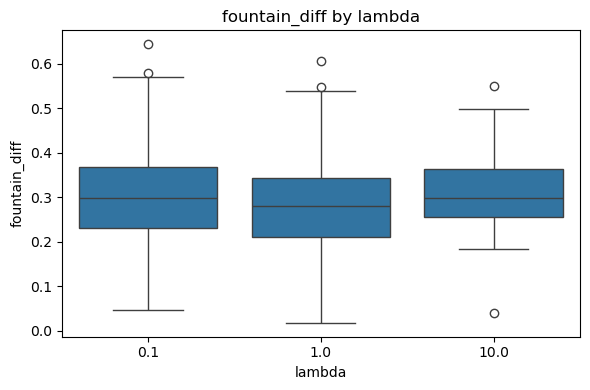

In [32]:
order = sorted(df["lambda"].unique())

plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="lambda", y="fountain_diff", order=order)
plt.xlabel("lambda")
plt.ylabel("fountain_diff")
plt.title("fountain_diff by lambda")
plt.tight_layout()
plt.show()

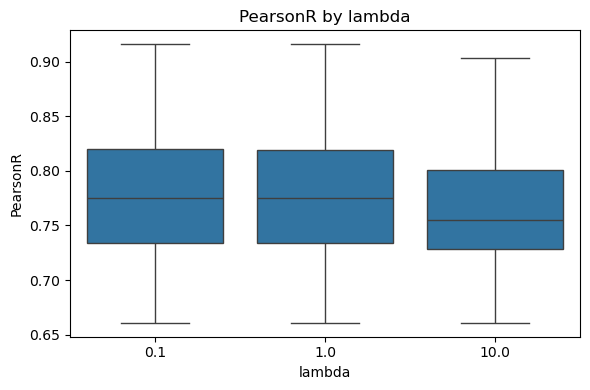

In [33]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="lambda", y="PearsonR", order=order)
plt.xlabel("lambda")
plt.ylabel("PearsonR")
plt.title("PearsonR by lambda")
plt.tight_layout()
plt.show()

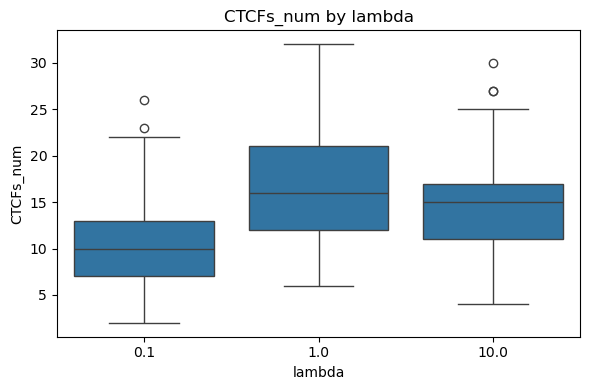

In [34]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="lambda", y="CTCFs_num", order=order)
plt.xlabel("lambda")
plt.ylabel("CTCFs_num")
plt.title("CTCFs_num by lambda")
plt.tight_layout()
plt.show()

In [36]:
df["init_CTCFs_num"].mean()

18.79236276849642

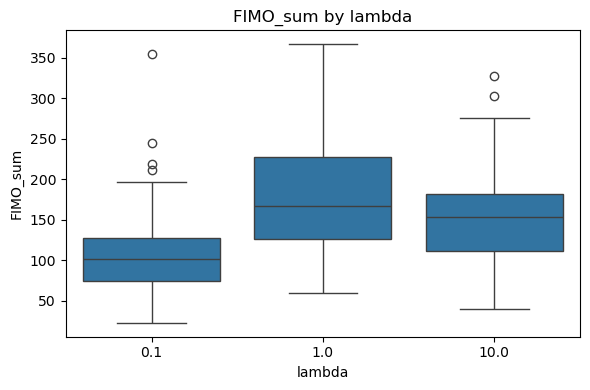

In [37]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="lambda", y="FIMO_sum", order=order)
plt.xlabel("lambda")
plt.ylabel("FIMO_sum")
plt.title("FIMO_sum by lambda")
plt.tight_layout()
plt.show()

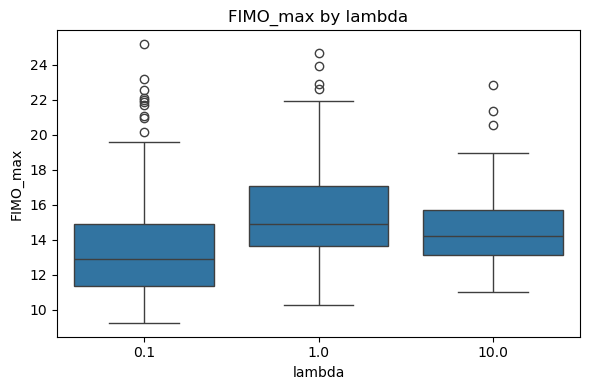

In [38]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="lambda", y="FIMO_max", order=order)
plt.xlabel("lambda")
plt.ylabel("FIMO_max")
plt.title("FIMO_max by lambda")
plt.tight_layout()
plt.show()